# Configuración del Entorno e Importaciones

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import warnings

from sklearn.model_selection import train_test_split
from sklearn.metrics import (confusion_matrix, classification_report, 
                             roc_auc_score, roc_curve, average_precision_score, 
                             precision_recall_curve, f1_score, recall_score, accuracy_score)
from scipy.stats import wilcoxon

# Importación específica de Mealpy según documentación oficial
from mealpy import FloatVar, GWO, MFO

# wilcoxon test for statistical significance
from scipy.stats import wilcoxon

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", context="paper")

# Carga y Preprocesamiento de Datos
Cargamos el dataset "default of credit card clients", eliminamos la columna ID (sin poder predictivo) y renombramos la variable objetivo para mayor claridad.

In [2]:
# Cargar el dataset (ajusta la ruta si es necesario)
df = pd.read_csv('/kaggle/input/datasets/mgoldyuwu/modelo-hibrido/default of credit card clients.csv', sep=',', skiprows=1)

# Renombrar variable objetivo y limpiar
if 'default payment next month' in df.columns:
    df.rename(columns={'default payment next month': 'target'}, inplace=True)

# Eliminar la columna ID
if 'ID' in df.columns:
    df.drop('ID', axis=1, inplace=True)

print(f"Dimensiones del dataset: {df.shape}")
display(df.head())

Dimensiones del dataset: (30000, 24)


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,target
0,20000,2,2,1,24,2,2,-1,-1,-2,...,0,0,0,0,689,0,0,0,0,1
1,120000,2,2,2,26,-1,2,0,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,2,2,2,34,0,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,50000,2,2,1,37,0,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,50000,1,2,1,57,-1,0,-1,0,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


# División Train/Test y Cálculo de Scale Pos Weight
- Usamos 80% para entrenamiento y 20% para prueba, con estratificación para mantener la proporción de clases.
- Calculamos el peso para penalizar más los errores en la clase minoritaria (Incumple = 1).

In [3]:
# Separar variables
X = df.drop('target', axis=1)
y = df['target']

# Dividir en conjuntos de entrenamiento y prueba (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Calcular el peso para balancear las clases
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
base_scale_pos_weight = neg / pos

print(f"Tamaño del set de entrenamiento: {X_train.shape}")
print(f"Tamaño del set de prueba: {X_test.shape}")
print(f"Scale Pos Weight calculado (Base): {base_scale_pos_weight:.4f}")

Tamaño del set de entrenamiento: (24000, 23)
Tamaño del set de prueba: (6000, 23)
Scale Pos Weight calculado (Base): 3.5206


# Entrenamiento del Modelo Base XGBoost
Configuramos el modelo base con los hiperparámetros por defecto del notebook original, habilitando GPU.

In [4]:
model_base = xgb.XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=base_scale_pos_weight,
    tree_method='hist',
    device='cuda',
    eval_metric='aucpr',
    early_stopping_rounds=50,
    random_state=42,
    verbosity=0
)

model_base.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)

# Predicciones
y_pred_base = model_base.predict(X_test)
y_pred_prob_base = model_base.predict_proba(X_test)[:, 1]

# Métricas Base
pr_auc_base = average_precision_score(y_test, y_pred_prob_base)
f1_base = f1_score(y_test, y_pred_base)
recall_base = recall_score(y_test, y_pred_base)
acc_base = accuracy_score(y_test, y_pred_base)

print(f"--- MÉTRICAS MODELO BASE ---")
print(f"PR-AUC: {pr_auc_base:.4f} | F1-Score: {f1_base:.4f} | Recall: {recall_base:.4f} | Accuracy: {acc_base:.4f}")

--- MÉTRICAS MODELO BASE ---
PR-AUC: 0.5557 | F1-Score: 0.5367 | Recall: 0.6066 | Accuracy: 0.7683


# Visualización del Modelo Base
Generamos la Matriz de Confusión, Curva ROC y Curva Precision-Recall para establecer la línea base.

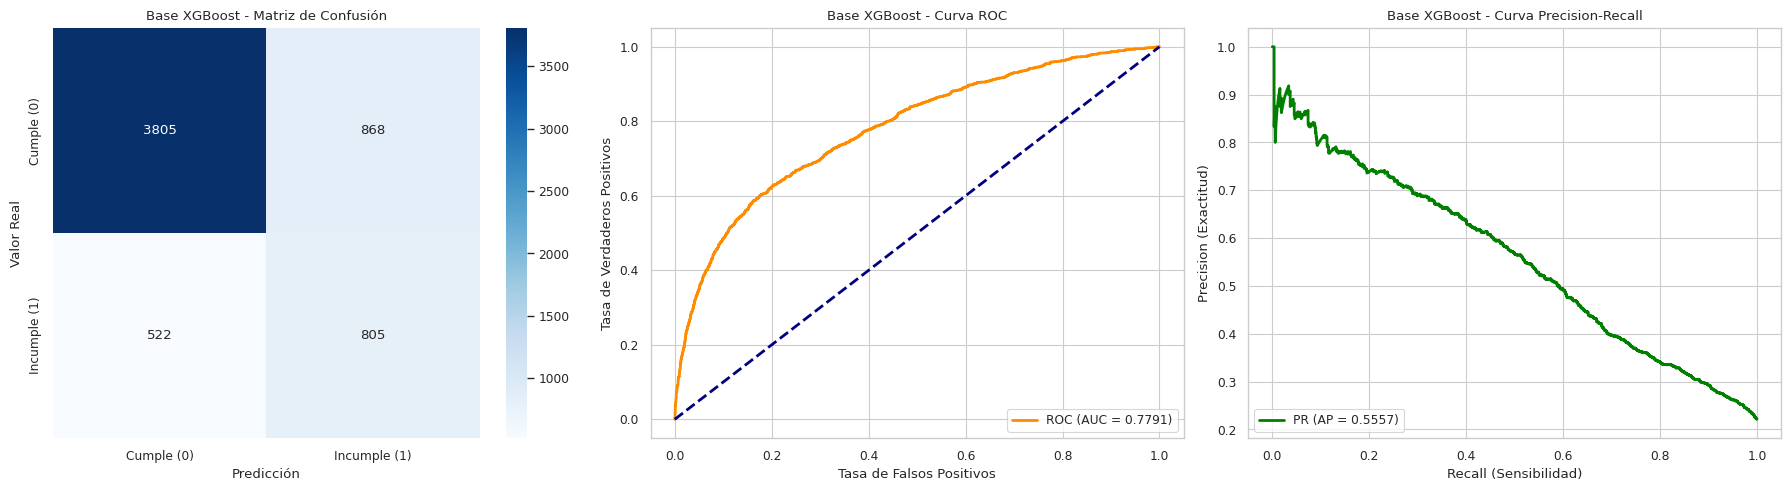

In [5]:
def plot_model_evaluation(y_test, y_pred, y_pred_prob, title_prefix="Modelo Base"):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # 1. Matriz de Confusión
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=['Cumple (0)', 'Incumple (1)'],
                yticklabels=['Cumple (0)', 'Incumple (1)'])
    axes[0].set_title(f'{title_prefix} - Matriz de Confusión')
    axes[0].set_ylabel('Valor Real')
    axes[0].set_xlabel('Predicción')

    # 2. Curva ROC
    fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
    roc_auc = roc_auc_score(y_test, y_pred_prob)
    axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC (AUC = {roc_auc:.4f})')
    axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    axes[1].set_xlabel('Tasa de Falsos Positivos')
    axes[1].set_ylabel('Tasa de Verdaderos Positivos')
    axes[1].set_title(f'{title_prefix} - Curva ROC')
    axes[1].legend(loc="lower right")

    # 3. Curva Precision-Recall
    precision, recall, _ = precision_recall_curve(y_test, y_pred_prob)
    pr_auc = average_precision_score(y_test, y_pred_prob)
    axes[2].plot(recall, precision, color='green', lw=2, label=f'PR (AP = {pr_auc:.4f})')
    axes[2].set_xlabel('Recall (Sensibilidad)')
    axes[2].set_ylabel('Precision (Exactitud)')
    axes[2].set_title(f'{title_prefix} - Curva Precision-Recall')
    axes[2].legend(loc="lower left")
    
    plt.tight_layout()
    plt.show()

plot_model_evaluation(y_test, y_pred_base, y_pred_prob_base, title_prefix="Base XGBoost")

# Función Objetivo y Límites para Grey Wolf Optimizer (GWO)
- Definimos los límites de búsqueda para los hiperparámetros. 
- La función objetivo devuelve `1 - PR_AUC` porque Mealpy minimiza por defecto.
- Se usa early_stopping para acelerar la evaluación durante la búsqueda.

In [6]:
# Límites de búsqueda (Lower Bound y Upper Bound)
# [n_estimators, max_depth, learning_rate, subsample, colsample_bytree, scale_pos_weight]
LB = [100, 3, 0.01, 0.6, 0.6, 2.0]
UB = [600, 10, 0.15, 1.0, 1.0, 5.0]

# ============================================
# CONFIGURACIÓN DE LA FUNCIÓN MULTI-OBJETIVO
# ============================================
# Pesos para cada métrica (deben sumar 1.0 si usas promedio ponderado)
W_PR_AUC = 0.5   # Peso para PR-AUC
W_F1     = 0.5   # Peso para F1-Score

# Umbral mínimo de Recall (penalización fuerte si baja de este valor)
MIN_RECALL_THRESHOLD = 0.55

# Modo de combinación: "geometric" (recomendado) o "weighted"
COMBINATION_MODE = "geometric"

def objective_function_gwo(solution):
    """
    Función objetivo MULTI-OBJETIVO que Mealpy intentará MINIMIZAR.
    Combina PR-AUC y F1-Score simultáneamente con penalización por Recall bajo.
    """
    n_estimators = int(solution[0])
    max_depth = int(solution[1])
    learning_rate = float(solution[2])
    subsample = float(solution[3])
    colsample_bytree = float(solution[4])
    scale_pos_weight = float(solution[5])
    
    # Entrenamiento rápido con early stopping
    model = xgb.XGBClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        learning_rate=learning_rate,
        subsample=subsample,
        colsample_bytree=colsample_bytree,
        scale_pos_weight=scale_pos_weight,
        tree_method='hist',
        device='cuda',
        eval_metric='aucpr',
        early_stopping_rounds=30,
        random_state=42,
        verbosity=0
    )
    
    model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)
    y_pred = model.predict(X_test)
    y_pred_prob = model.predict_proba(X_test)[:, 1]
    
    # Calcular métricas clave
    pr_auc = average_precision_score(y_test, y_pred_prob)
    f1     = f1_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    
    # ============================================
    # COMBINACIÓN DE MÉTRICAS (Multi-Objetivo)
    # ============================================
    if COMBINATION_MODE == "geometric":
        # Producto geométrico: exige que AMBAS métricas sean altas
        # Si una es baja, el resultado cae drásticamente
        combined_score = np.sqrt(pr_auc * f1)
    else:
        # Promedio ponderado: permite compensar métricas
        combined_score = (W_PR_AUC * pr_auc) + (W_F1 * f1)
    
    # ============================================
    # PENALIZACIÓN POR RECALL BAJO
    # ============================================
    # Si el recall cae por debajo del umbral, penalización fuerte
    # Esto es CRÍTICO en detección de fraude/morosidad
    if recall < MIN_RECALL_THRESHOLD:
        penalty = (MIN_RECALL_THRESHOLD - recall) * 0.8
    else:
        penalty = 0.0
    
    # Mealpy MINIMIZA, por eso devolvemos (1 - score) + penalización
    return (1.0 - combined_score) + penalty

# Diccionario del problema según documentación oficial de Mealpy
problem_dict = {
    "obj_func": objective_function_gwo,
    "bounds": FloatVar(lb=LB, ub=UB, name="xgb_hyperparams"),
    "minmax": "min",
}

# Optimización GWO (20 Iteraciones)
Configuramos el enjambre de lobos grises con 20 épocas y un tamaño de población de 20.

In [7]:
gwo_20_model = GWO.OriginalGWO(epoch=20, pop_size=20)
gwo_20_best = gwo_20_model.solve(problem_dict)

print("Optimización 20 iteraciones completada.")
print(f"Mejor fitness (1 - PR_AUC): {gwo_20_best.target.fitness:.4f}")
print(f"Mejores hiperparámetros encontrados: {np.round(gwo_20_best.solution, 4)}")

# Extraer hiperparámetros óptimos
best_params_20 = {
    "n_estimators": int(gwo_20_best.solution[0]),
    "max_depth": int(gwo_20_best.solution[1]),
    "learning_rate": float(gwo_20_best.solution[2]),
    "subsample": float(gwo_20_best.solution[3]),
    "colsample_bytree": float(gwo_20_best.solution[4]),
    "scale_pos_weight": float(gwo_20_best.solution[5])
}

2026/07/22 04:31:47 AM, INFO, mealpy.swarm_based.GWO.OriginalGWO: OriginalGWO(epoch=20, pop_size=20)
2026/07/22 04:32:01 AM, INFO, mealpy.swarm_based.GWO.OriginalGWO: >>>Problem: P, Epoch: 1, Current best: 0.45066819674213854, Global best: 0.45066819674213854, Runtime: 7.08445 seconds
2026/07/22 04:32:07 AM, INFO, mealpy.swarm_based.GWO.OriginalGWO: >>>Problem: P, Epoch: 2, Current best: 0.448663798490469, Global best: 0.448663798490469, Runtime: 5.74913 seconds
2026/07/22 04:32:12 AM, INFO, mealpy.swarm_based.GWO.OriginalGWO: >>>Problem: P, Epoch: 3, Current best: 0.448663798490469, Global best: 0.448663798490469, Runtime: 5.10569 seconds
2026/07/22 04:32:18 AM, INFO, mealpy.swarm_based.GWO.OriginalGWO: >>>Problem: P, Epoch: 4, Current best: 0.445620812165727, Global best: 0.445620812165727, Runtime: 5.85380 seconds
2026/07/22 04:32:23 AM, INFO, mealpy.swarm_based.GWO.OriginalGWO: >>>Problem: P, Epoch: 5, Current best: 0.445620812165727, Global best: 0.445620812165727, Runtime: 5.5829

Optimización 20 iteraciones completada.
Mejor fitness (1 - PR_AUC): 0.4434
Mejores hiperparámetros encontrados: [2.347734e+02 3.472200e+00 1.021000e-01 6.271000e-01 6.242000e-01
 3.220800e+00]


# Entrenamiento Final y Evaluación del Modelo  GWO (20 Iteraciones)
Entrenamos el modelo final con los hiperparámetros óptimos sin early stopping agresivo para máxima precisión.

--- MÉTRICAS GWO (20 Iteraciones) ---
PR-AUC: 0.5638 | F1-Score: 0.5495 | Recall: 0.6081 | Accuracy: 0.7795


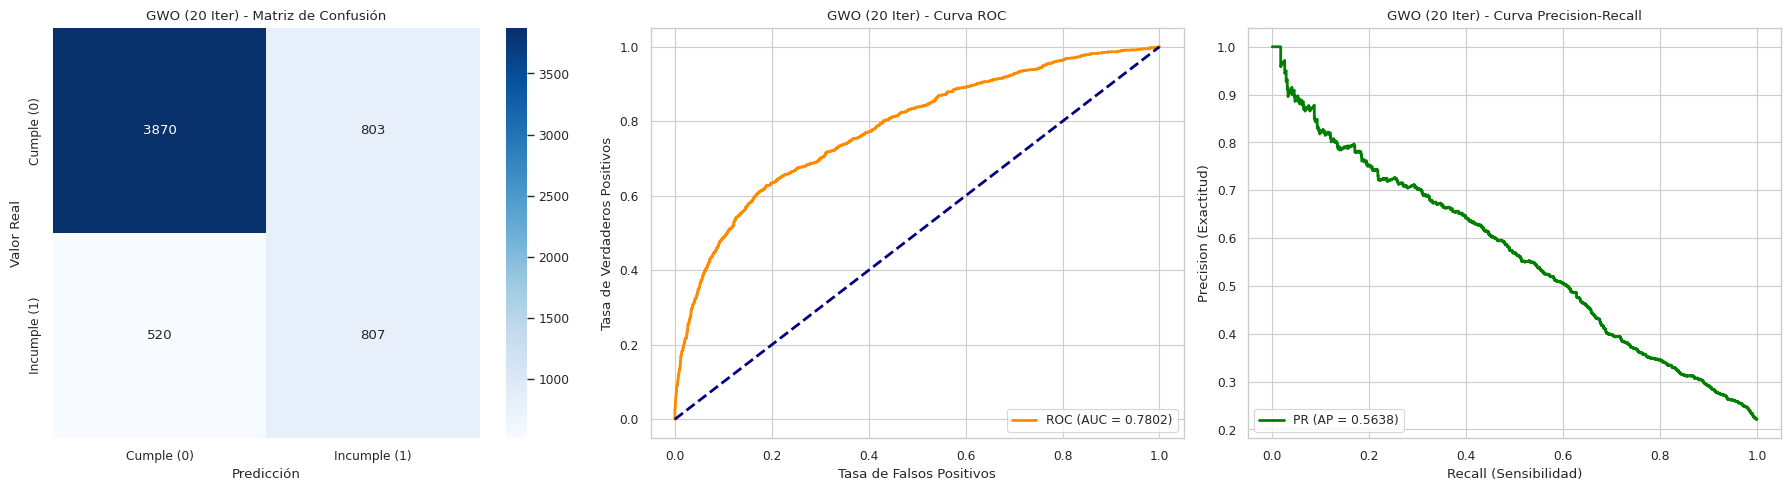

In [8]:
model_gwo_20 = xgb.XGBClassifier(
    **best_params_20,
    tree_method='hist',
    device='cuda',
    eval_metric='aucpr',
    early_stopping_rounds=50,
    random_state=42,
    verbosity=0
)
model_gwo_20.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)

y_pred_gwo_20 = model_gwo_20.predict(X_test)
y_pred_prob_gwo_20 = model_gwo_20.predict_proba(X_test)[:, 1]

pr_auc_20 = average_precision_score(y_test, y_pred_prob_gwo_20)
f1_20 = f1_score(y_test, y_pred_gwo_20)
recall_20 = recall_score(y_test, y_pred_gwo_20)
acc_20 = accuracy_score(y_test, y_pred_gwo_20)

print(f"--- MÉTRICAS GWO (20 Iteraciones) ---")
print(f"PR-AUC: {pr_auc_20:.4f} | F1-Score: {f1_20:.4f} | Recall: {recall_20:.4f} | Accuracy: {acc_20:.4f}")

plot_model_evaluation(y_test, y_pred_gwo_20, y_pred_prob_gwo_20, title_prefix="GWO (20 Iter)")

# Optimización GWO (50 Iteraciones)
Aumentamos las épocas a 50 para permitir una mayor explotación del espacio de búsqueda.

In [9]:
gwo_50_model = GWO.OriginalGWO(epoch=50, pop_size=20)
gwo_50_best = gwo_50_model.solve(problem_dict)

print("Optimización 50 iteraciones completada.")
print(f"Mejor fitness (1 - PR_AUC): {gwo_50_best.target.fitness:.4f}")
print(f"Mejores hiperparámetros encontrados: {np.round(gwo_50_best.solution, 4)}")

best_params_50 = {
    "n_estimators": int(gwo_50_best.solution[0]),
    "max_depth": int(gwo_50_best.solution[1]),
    "learning_rate": float(gwo_50_best.solution[2]),
    "subsample": float(gwo_50_best.solution[3]),
    "colsample_bytree": float(gwo_50_best.solution[4]),
    "scale_pos_weight": float(gwo_50_best.solution[5])
}

2026/07/22 04:33:41 AM, INFO, mealpy.swarm_based.GWO.OriginalGWO: OriginalGWO(epoch=50, pop_size=20)
2026/07/22 04:33:53 AM, INFO, mealpy.swarm_based.GWO.OriginalGWO: >>>Problem: P, Epoch: 1, Current best: 0.4494969975736225, Global best: 0.4494969975736225, Runtime: 6.05981 seconds
2026/07/22 04:33:58 AM, INFO, mealpy.swarm_based.GWO.OriginalGWO: >>>Problem: P, Epoch: 2, Current best: 0.44677285989625126, Global best: 0.44677285989625126, Runtime: 5.37660 seconds
2026/07/22 04:34:03 AM, INFO, mealpy.swarm_based.GWO.OriginalGWO: >>>Problem: P, Epoch: 3, Current best: 0.44677285989625126, Global best: 0.44677285989625126, Runtime: 5.42342 seconds
2026/07/22 04:34:09 AM, INFO, mealpy.swarm_based.GWO.OriginalGWO: >>>Problem: P, Epoch: 4, Current best: 0.44677285989625126, Global best: 0.44677285989625126, Runtime: 5.66706 seconds
2026/07/22 04:34:14 AM, INFO, mealpy.swarm_based.GWO.OriginalGWO: >>>Problem: P, Epoch: 5, Current best: 0.44677285989625126, Global best: 0.44677285989625126, R

Optimización 50 iteraciones completada.
Mejor fitness (1 - PR_AUC): 0.4423
Mejores hiperparámetros encontrados: [3.095481e+02 4.665100e+00 1.229000e-01 1.000000e+00 6.000000e-01
 3.223800e+00]


# Entrenamiento Final y Evaluación del Modelo GWO (50 Iteraciones)

--- MÉTRICAS GWO (50 Iteraciones) ---
PR-AUC: 0.5648 | F1-Score: 0.5507 | Recall: 0.6096 | Accuracy: 0.7800


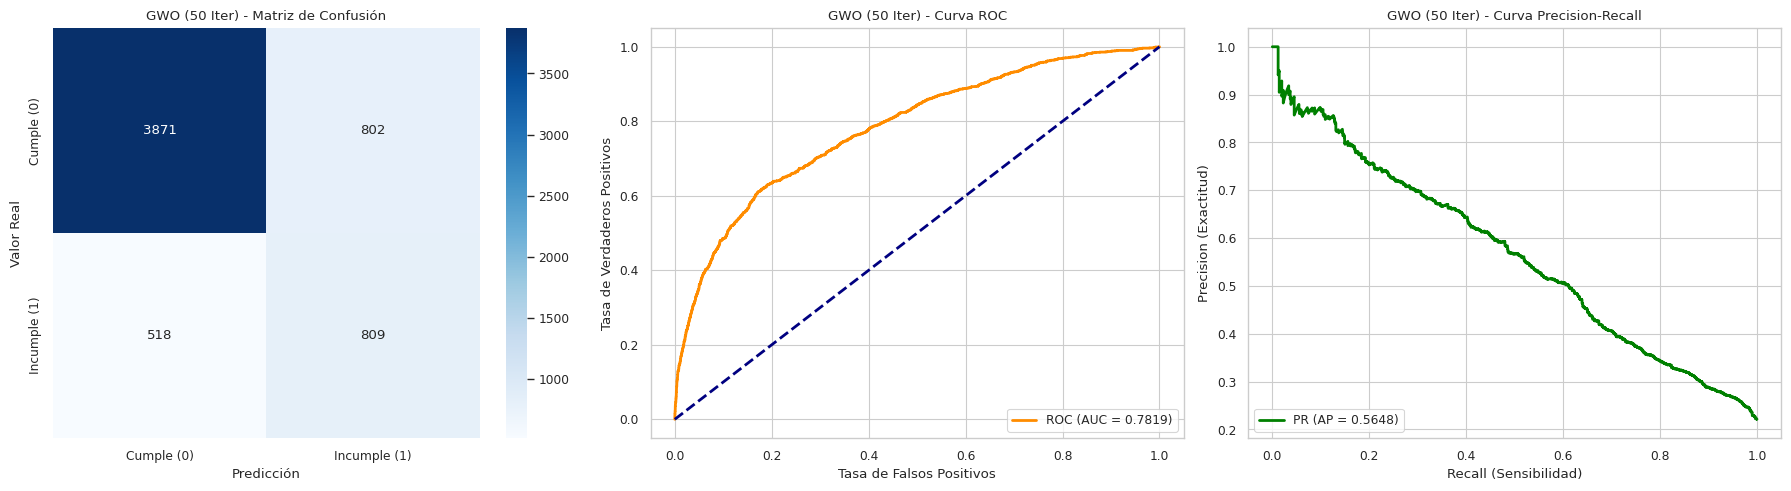

In [10]:
model_gwo_50 = xgb.XGBClassifier(
    **best_params_50,
    tree_method='hist',
    device='cuda',
    eval_metric='aucpr',
    early_stopping_rounds=50,
    random_state=42,
    verbosity=0
)
model_gwo_50.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)

y_pred_gwo_50 = model_gwo_50.predict(X_test)
y_pred_prob_gwo_50 = model_gwo_50.predict_proba(X_test)[:, 1]

pr_auc_50 = average_precision_score(y_test, y_pred_prob_gwo_50)
f1_50 = f1_score(y_test, y_pred_gwo_50)
recall_50 = recall_score(y_test, y_pred_gwo_50)
acc_50 = accuracy_score(y_test, y_pred_gwo_50)

print(f"--- MÉTRICAS GWO (50 Iteraciones) ---")
print(f"PR-AUC: {pr_auc_50:.4f} | F1-Score: {f1_50:.4f} | Recall: {recall_50:.4f} | Accuracy: {acc_50:.4f}")

plot_model_evaluation(y_test, y_pred_gwo_50, y_pred_prob_gwo_50, title_prefix="GWO (50 Iter)")

# Optimización Híbrida GWO + MFO (20 + 20 Iteraciones)
- **FASE 1**: GWO con 20 épocas realiza la búsqueda global.
- **FASE 2**: MFO con 20 épocas refina localmente alrededor del mejor resultado de GWO (±20% del rango).
- Esta configuración es equivalente en coste computacional a GWO (40 iter) pero con mejor exploración-explotación.

In [11]:
# ============================================
# FASE 1: GWO GLOBAL (20 épocas)
# ============================================
print("🐺 FASE 1: Grey Wolf Optimizer - Búsqueda Global (20 épocas)")
gwo_20_hib = GWO.OriginalGWO(epoch=20, pop_size=20)
gwo_20_hib_best = gwo_20_hib.solve(problem_dict)

print(f"✅ Mejor fitness GWO: {gwo_20_hib_best.target.fitness:.4f}")
print(f"📍 Mejores hiperparámetros GWO: {np.round(gwo_20_hib_best.solution, 4)}")

# ============================================
# FASE 2: MFO LOCAL (20 épocas) - Refinamiento
# ============================================
print("\n🦋 FASE 2: Moth-Flame Optimization - Refinamiento Local (20 épocas)")

# Definir límites locales alrededor del mejor resultado de GWO (±20%)
best_gwo = gwo_20_hib_best.solution
margin = 0.20

LB_local = []
UB_local = []
for i, (lb, ub, best_val) in enumerate(zip(LB, UB, best_gwo)):
    range_val = ub - lb
    local_margin = range_val * margin
    lb_local = max(lb, best_val - local_margin)
    ub_local = min(ub, best_val + local_margin)
    LB_local.append(lb_local)
    UB_local.append(ub_local)

print(f"🔍 Límites locales para MFO (±{margin*100}% del mejor GWO):")
print(f"   LB_local: {np.round(LB_local, 4)}")
print(f"   UB_local: {np.round(UB_local, 4)}")

# Problema local para MFO
problem_dict_local = {
    "obj_func": objective_function_gwo,
    "bounds": FloatVar(lb=LB_local, ub=UB_local, name="xgb_hyperparams_local"),
    "minmax": "min",
}

mfo_20 = MFO.OriginalMFO(epoch=20, pop_size=20)
mfo_20_best = mfo_20.solve(problem_dict_local)

print(f"\n✅ Mejor fitness MFO (refinado): {mfo_20_best.target.fitness:.4f}")
print(f"📍 Mejores hiperparámetros Híbrido (20+20): {np.round(mfo_20_best.solution, 4)}")

# Extraer hiperparámetros óptimos del híbrido 20+20
best_params_hybrid_20 = {
    "n_estimators": int(mfo_20_best.solution[0]),
    "max_depth": int(mfo_20_best.solution[1]),
    "learning_rate": float(mfo_20_best.solution[2]),
    "subsample": float(mfo_20_best.solution[3]),
    "colsample_bytree": float(mfo_20_best.solution[4]),
    "scale_pos_weight": float(mfo_20_best.solution[5])
}

2026/07/22 04:37:47 AM, INFO, mealpy.swarm_based.GWO.OriginalGWO: OriginalGWO(epoch=20, pop_size=20)


🐺 FASE 1: Grey Wolf Optimizer - Búsqueda Global (20 épocas)


2026/07/22 04:38:00 AM, INFO, mealpy.swarm_based.GWO.OriginalGWO: >>>Problem: P, Epoch: 1, Current best: 0.448310252385808, Global best: 0.448310252385808, Runtime: 6.20036 seconds
2026/07/22 04:38:07 AM, INFO, mealpy.swarm_based.GWO.OriginalGWO: >>>Problem: P, Epoch: 2, Current best: 0.448310252385808, Global best: 0.448310252385808, Runtime: 7.05185 seconds
2026/07/22 04:38:13 AM, INFO, mealpy.swarm_based.GWO.OriginalGWO: >>>Problem: P, Epoch: 3, Current best: 0.4425085195761551, Global best: 0.4425085195761551, Runtime: 5.93236 seconds
2026/07/22 04:38:18 AM, INFO, mealpy.swarm_based.GWO.OriginalGWO: >>>Problem: P, Epoch: 4, Current best: 0.4425085195761551, Global best: 0.4425085195761551, Runtime: 5.13645 seconds
2026/07/22 04:38:23 AM, INFO, mealpy.swarm_based.GWO.OriginalGWO: >>>Problem: P, Epoch: 5, Current best: 0.4425085195761551, Global best: 0.4425085195761551, Runtime: 4.70591 seconds
2026/07/22 04:38:28 AM, INFO, mealpy.swarm_based.GWO.OriginalGWO: >>>Problem: P, Epoch: 6

✅ Mejor fitness GWO: 0.4425
📍 Mejores hiperparámetros GWO: [6.0000e+02 4.6438e+00 1.1860e-01 1.0000e+00 6.0000e-01 3.1156e+00]

🦋 FASE 2: Moth-Flame Optimization - Refinamiento Local (20 épocas)
🔍 Límites locales para MFO (±20.0% del mejor GWO):
   LB_local: [5.0000e+02 3.2438e+00 9.0600e-02 9.2000e-01 6.0000e-01 2.5156e+00]
   UB_local: [6.0000e+02 6.0438e+00 1.4660e-01 1.0000e+00 6.8000e-01 3.7156e+00]


2026/07/22 04:39:42 AM, INFO, mealpy.swarm_based.MFO.OriginalMFO: >>>Problem: P, Epoch: 1, Current best: 0.4465463610853616, Global best: 0.4465463610853616, Runtime: 4.54264 seconds
2026/07/22 04:39:47 AM, INFO, mealpy.swarm_based.MFO.OriginalMFO: >>>Problem: P, Epoch: 2, Current best: 0.4455290335345363, Global best: 0.4455290335345363, Runtime: 4.65869 seconds
2026/07/22 04:39:52 AM, INFO, mealpy.swarm_based.MFO.OriginalMFO: >>>Problem: P, Epoch: 3, Current best: 0.4455290335345363, Global best: 0.4455290335345363, Runtime: 4.83964 seconds
2026/07/22 04:39:56 AM, INFO, mealpy.swarm_based.MFO.OriginalMFO: >>>Problem: P, Epoch: 4, Current best: 0.44475623677482223, Global best: 0.44475623677482223, Runtime: 4.77226 seconds
2026/07/22 04:40:01 AM, INFO, mealpy.swarm_based.MFO.OriginalMFO: >>>Problem: P, Epoch: 5, Current best: 0.44475623677482223, Global best: 0.44475623677482223, Runtime: 4.74544 seconds
2026/07/22 04:40:05 AM, INFO, mealpy.swarm_based.MFO.OriginalMFO: >>>Problem: P, 


✅ Mejor fitness MFO (refinado): 0.4435
📍 Mejores hiperparámetros Híbrido (20+20): [6.0000e+02 4.3794e+00 1.4660e-01 1.0000e+00 6.3980e-01 3.2961e+00]


# Entrenamiento Final y Evaluación del Modelo Híbrido (20+20)
Entrenamos el modelo híbrido con los hiperparámetros refinados por MFO tras la búsqueda global de GWO.

- MÉTRICAS Híbrido GWO+MFO (20+20 Iter) -
PR-AUC: 0.5639| F1-Score: 0.5493| Recall: 0.6172| Accuracy: 0.7760


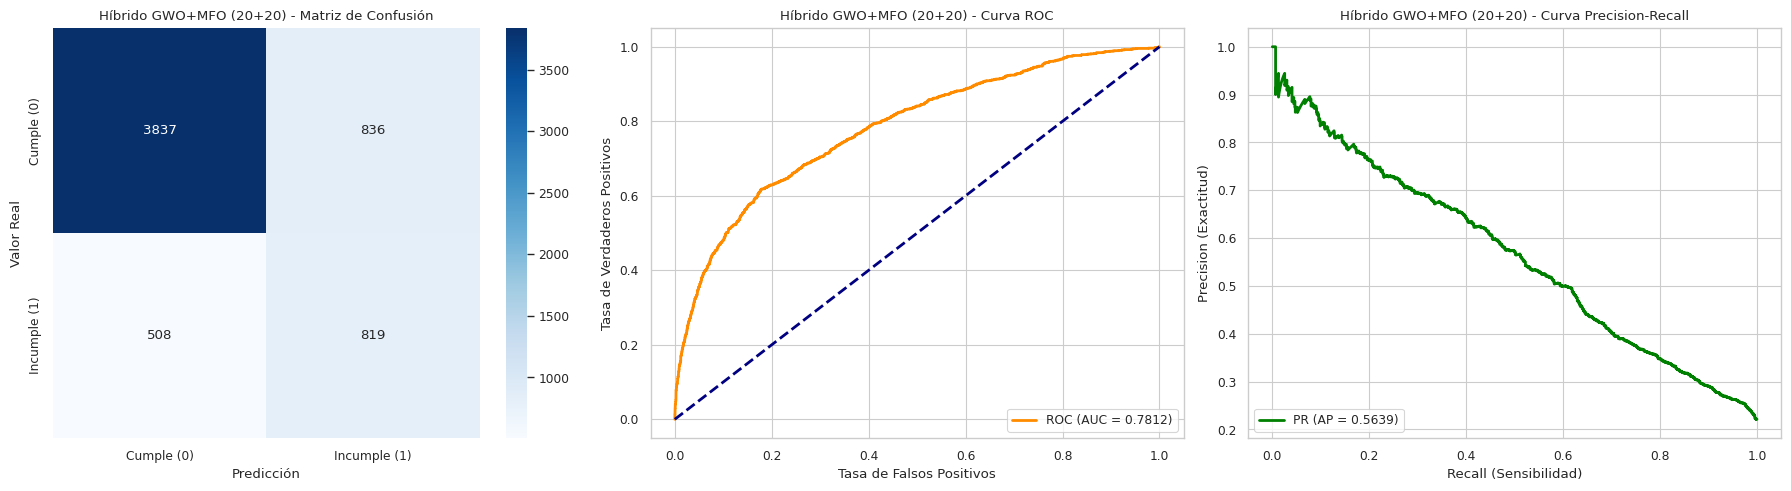

In [12]:
model_hybrid_20 = xgb.XGBClassifier(
    **best_params_hybrid_20,
    tree_method='hist',
    device='cuda',
    eval_metric='aucpr',
    early_stopping_rounds=50,
    random_state=42,
    verbosity=0
)
model_hybrid_20.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)

y_pred_hybrid_20 = model_hybrid_20.predict(X_test)
y_pred_prob_hybrid_20 = model_hybrid_20.predict_proba(X_test)[:, 1]

pr_auc_hybrid_20 = average_precision_score(y_test, y_pred_prob_hybrid_20)
f1_hybrid_20 = f1_score(y_test, y_pred_hybrid_20)
recall_hybrid_20 = recall_score(y_test, y_pred_hybrid_20)
acc_hybrid_20 = accuracy_score(y_test, y_pred_hybrid_20)

print(f"- MÉTRICAS Híbrido GWO+MFO (20+20 Iter) -")
print(f"PR-AUC: {pr_auc_hybrid_20:.4f}| F1-Score: {f1_hybrid_20:.4f}| Recall: {recall_hybrid_20:.4f}| Accuracy: {acc_hybrid_20:.4f}")

plot_model_evaluation(y_test, y_pred_hybrid_20, y_pred_prob_hybrid_20, 
                     title_prefix="Híbrido GWO+MFO (20+20)")

# Optimización Híbrida GWO + MFO (50 + 20 Iteraciones)
- **FASE 1**: GWO con 50 épocas (mayor exploración global).
- **FASE 2**: MFO con 20 épocas refina localmente.
- Esta configuración aprovecha la mayor convergencia de GWO (50) antes del refinamiento de MFO.

In [13]:
# ============================================
# FASE 1: GWO GLOBAL (50 épocas)
# ============================================
print("🐺 FASE 1: Grey Wolf Optimizer - Búsqueda Global (50 épocas)")
gwo_50_hib = GWO.OriginalGWO(epoch=50, pop_size=20)
gwo_50_hib_best = gwo_50_hib.solve(problem_dict)

print(f"✅ Mejor fitness GWO: {gwo_50_hib_best.target.fitness:.4f}")
print(f"📍 Mejores hiperparámetros GWO: {np.round(gwo_50_hib_best.solution, 4)}")

# ============================================
# FASE 2: MFO LOCAL (20 épocas)
# ============================================
print("\n🦋 FASE 2: Moth-Flame Optimization - Refinamiento Local (20 épocas)")

best_gwo_50 = gwo_50_hib_best.solution
LB_local_50 = [max(lb, best - (ub - lb) * margin) for lb, ub, best in zip(LB, UB, best_gwo_50)]
UB_local_50 = [min(ub, best + (ub - lb) * margin) for lb, ub, best in zip(LB, UB, best_gwo_50)]

print(f"🔍 Límites locales para MFO (±{margin*100}% del mejor GWO):")
print(f"   LB_local: {np.round(LB_local_50, 4)}")
print(f"   UB_local: {np.round(UB_local_50, 4)}")

problem_dict_local_50 = {
    "obj_func": objective_function_gwo,
    "bounds": FloatVar(lb=LB_local_50, ub=UB_local_50, name="xgb_hyperparams_local_50"),
    "minmax": "min",
}

mfo_50_20 = MFO.OriginalMFO(epoch=20, pop_size=20)
mfo_50_20_best = mfo_50_20.solve(problem_dict_local_50)

print(f"\n✅ Mejor fitness MFO (refinado): {mfo_50_20_best.target.fitness:.4f}")
print(f"📍 Mejores hiperparámetros Híbrido (50+20): {np.round(mfo_50_20_best.solution, 4)}")

best_params_hybrid_50 = {
    "n_estimators": int(mfo_50_20_best.solution[0]),
    "max_depth": int(mfo_50_20_best.solution[1]),
    "learning_rate": float(mfo_50_20_best.solution[2]),
    "subsample": float(mfo_50_20_best.solution[3]),
    "colsample_bytree": float(mfo_50_20_best.solution[4]),
    "scale_pos_weight": float(mfo_50_20_best.solution[5])
}

2026/07/22 04:41:08 AM, INFO, mealpy.swarm_based.GWO.OriginalGWO: OriginalGWO(epoch=50, pop_size=20)


🐺 FASE 1: Grey Wolf Optimizer - Búsqueda Global (50 épocas)


2026/07/22 04:41:20 AM, INFO, mealpy.swarm_based.GWO.OriginalGWO: >>>Problem: P, Epoch: 1, Current best: 0.4506373700312739, Global best: 0.4506373700312739, Runtime: 5.34252 seconds
2026/07/22 04:41:26 AM, INFO, mealpy.swarm_based.GWO.OriginalGWO: >>>Problem: P, Epoch: 2, Current best: 0.4489784501571872, Global best: 0.4489784501571872, Runtime: 6.00926 seconds
2026/07/22 04:41:31 AM, INFO, mealpy.swarm_based.GWO.OriginalGWO: >>>Problem: P, Epoch: 3, Current best: 0.4485499201956098, Global best: 0.4485499201956098, Runtime: 5.46340 seconds
2026/07/22 04:41:38 AM, INFO, mealpy.swarm_based.GWO.OriginalGWO: >>>Problem: P, Epoch: 4, Current best: 0.4485499201956098, Global best: 0.4485499201956098, Runtime: 6.98246 seconds
2026/07/22 04:41:44 AM, INFO, mealpy.swarm_based.GWO.OriginalGWO: >>>Problem: P, Epoch: 5, Current best: 0.4485499201956098, Global best: 0.4485499201956098, Runtime: 5.90775 seconds
2026/07/22 04:41:50 AM, INFO, mealpy.swarm_based.GWO.OriginalGWO: >>>Problem: P, Epoc

✅ Mejor fitness GWO: 0.4438
📍 Mejores hiperparámetros GWO: [2.590086e+02 4.188300e+00 1.099000e-01 9.112000e-01 6.134000e-01
 3.226700e+00]

🦋 FASE 2: Moth-Flame Optimization - Refinamiento Local (20 épocas)
🔍 Límites locales para MFO (±20.0% del mejor GWO):
   LB_local: [1.590086e+02 3.000000e+00 8.190000e-02 8.312000e-01 6.000000e-01
 2.626700e+00]
   UB_local: [3.590086e+02 5.588300e+00 1.379000e-01 9.912000e-01 6.934000e-01
 3.826700e+00]


2026/07/22 04:45:45 AM, INFO, mealpy.swarm_based.MFO.OriginalMFO: >>>Problem: P, Epoch: 1, Current best: 0.44578927090463183, Global best: 0.44578927090463183, Runtime: 4.76317 seconds
2026/07/22 04:45:50 AM, INFO, mealpy.swarm_based.MFO.OriginalMFO: >>>Problem: P, Epoch: 2, Current best: 0.44578927090463183, Global best: 0.44578927090463183, Runtime: 4.83350 seconds
2026/07/22 04:45:55 AM, INFO, mealpy.swarm_based.MFO.OriginalMFO: >>>Problem: P, Epoch: 3, Current best: 0.44560132033986855, Global best: 0.44560132033986855, Runtime: 4.85004 seconds
2026/07/22 04:45:59 AM, INFO, mealpy.swarm_based.MFO.OriginalMFO: >>>Problem: P, Epoch: 4, Current best: 0.44560132033986855, Global best: 0.44560132033986855, Runtime: 4.81018 seconds
2026/07/22 04:46:04 AM, INFO, mealpy.swarm_based.MFO.OriginalMFO: >>>Problem: P, Epoch: 5, Current best: 0.44560132033986855, Global best: 0.44560132033986855, Runtime: 4.77892 seconds
2026/07/22 04:46:09 AM, INFO, mealpy.swarm_based.MFO.OriginalMFO: >>>Proble


✅ Mejor fitness MFO (refinado): 0.4439
📍 Mejores hiperparámetros Híbrido (50+20): [3.555529e+02 4.885100e+00 1.292000e-01 8.969000e-01 6.790000e-01
 3.287300e+00]


# Entrenamiento Final y Evaluación del Modelo Híbrido (50+20)

- MÉTRICAS Híbrido GWO+MFO (50+20 Iter) -
PR-AUC: 0.5615| F1-Score: 0.5508| Recall: 0.6187| Accuracy: 0.7768


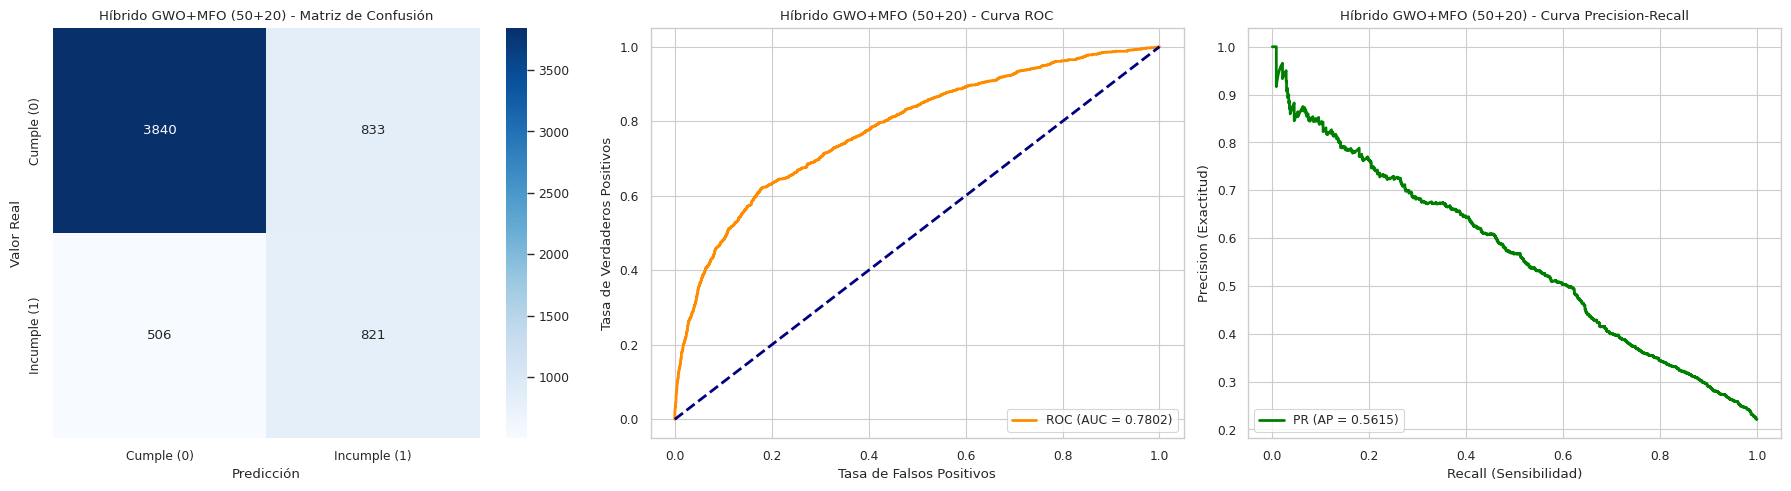

In [14]:
model_hybrid_50 = xgb.XGBClassifier(
    **best_params_hybrid_50,
    tree_method='hist',
    device='cuda',
    eval_metric='aucpr',
    early_stopping_rounds=50,
    random_state=42,
    verbosity=0
)
model_hybrid_50.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)

y_pred_hybrid_50 = model_hybrid_50.predict(X_test)
y_pred_prob_hybrid_50 = model_hybrid_50.predict_proba(X_test)[:, 1]

pr_auc_hybrid_50 = average_precision_score(y_test, y_pred_prob_hybrid_50)
f1_hybrid_50 = f1_score(y_test, y_pred_hybrid_50)
recall_hybrid_50 = recall_score(y_test, y_pred_hybrid_50)
acc_hybrid_50 = accuracy_score(y_test, y_pred_hybrid_50)

print(f"- MÉTRICAS Híbrido GWO+MFO (50+20 Iter) -")
print(f"PR-AUC: {pr_auc_hybrid_50:.4f}| F1-Score: {f1_hybrid_50:.4f}| Recall: {recall_hybrid_50:.4f}| Accuracy: {acc_hybrid_50:.4f}")

plot_model_evaluation(y_test, y_pred_hybrid_50, y_pred_prob_hybrid_50, 
                     title_prefix="Híbrido GWO+MFO (50+20)")

# Tabla Comparativa de Rendimiento
Consolidamos las métricas para su inclusión directa en el paper.

In [15]:
comparison_df = pd.DataFrame({
    "Modelo": ["XGBoost Base", "GWO (20 Iter)", "GWO (50 Iter)", 
               "Híbrido GWO+MFO (20+20)", "Híbrido GWO+MFO (50+20)"],
    "PR-AUC": [pr_auc_base, pr_auc_20, pr_auc_50, pr_auc_hybrid_20, pr_auc_hybrid_50],
    "F1-Score": [f1_base, f1_20, f1_50, f1_hybrid_20, f1_hybrid_50],
    "Recall": [recall_base, recall_20, recall_50, recall_hybrid_20, recall_hybrid_50],
    "Accuracy": [acc_base, acc_20, acc_50, acc_hybrid_20, acc_hybrid_50],
    "Geo-Mean": [
        np.sqrt(pr_auc_base * f1_base),
        np.sqrt(pr_auc_20 * f1_20),
        np.sqrt(pr_auc_50 * f1_50),
        np.sqrt(pr_auc_hybrid_20 * f1_hybrid_20),
        np.sqrt(pr_auc_hybrid_50 * f1_hybrid_50)
    ]
})

comparison_df["Δ PR-AUC"] = comparison_df["PR-AUC"].apply(
    lambda x: f"+{((x/pr_auc_base)-1)*100:.2f}%"
)
comparison_df["Δ F1"] = comparison_df["F1-Score"].apply(
    lambda x: f"+{((x/f1_base)-1)*100:.2f}%"
)
comparison_df["Δ Geo-Mean"] = comparison_df["Geo-Mean"].apply(
    lambda x: f"+{((x/np.sqrt(pr_auc_base * f1_base))-1)*100:.2f}%"
)

print("\n📊 TABLA COMPARATIVA MULTI-OBJETIVO")
display(comparison_df.style.highlight_max(
    subset=["PR-AUC", "F1-Score", "Recall", "Accuracy", "Geo-Mean"],
    color='green'
))


📊 TABLA COMPARATIVA MULTI-OBJETIVO


,Modelo,PR-AUC,F1-Score,Recall,Accuracy,Geo-Mean,Δ PR-AUC,Δ F1,Δ Geo-Mean
0,XGBoost Base,0.555654,0.536667,0.606631,0.768333,0.546078,+0.00%,+0.00%,+0.00%
1,GWO (20 Iter),0.563841,0.549540,0.608139,0.779500,0.556645,+1.47%,+2.40%,+1.94%
2,GWO (50 Iter),0.564830,0.550715,0.609646,0.780000,0.557728,+1.65%,+2.62%,+2.13%
3,Híbrido GWO+MFO (20+20),0.563880,0.549296,0.617182,0.776000,0.556540,+1.48%,+2.35%,+1.92%
4,Híbrido GWO+MFO (50+20),0.561455,0.550822,0.618689,0.776833,0.556113,+1.04%,+2.64%,+1.84%


# Análisis de Robustez Estadística
- Ejecutamos GWO (20 y 50 iteraciones) 15 veces con diferentes semillas aleatorias.
- Esto demuestra que la mejora no es un golpe de suerte, sino que el algoritmo es estable (varianza baja).
- NOTA: Esta celda puede tomar varios minutos debido a las 30 evaluaciones de modelo por ejecución.

In [16]:
# ============================================
# ANÁLISIS DE ROBUSTEZ ESTADÍSTICA (CORREGIDO)
# ============================================
seeds = [42, 123, 456, 789, 1011, 1213, 1415, 1617, 1819, 2021,
         2223, 2425, 2627, 2829, 3031]

results_base_robust = []
results_gwo_20_robust = []
results_gwo_50_robust = []
results_hybrid_20_robust = []
results_hybrid_50_robust = []

print("Iniciando análisis de robustez (15 ejecuciones por configuración)...")

for i, seed in enumerate(seeds):
    print(f" Ejecución {i+1}/15 (Seed: {seed})")
    
    # Modelo Base
    mb = xgb.XGBClassifier(n_estimators=500, max_depth=6, learning_rate=0.05,
                           subsample=0.8, colsample_bytree=0.8,
                           scale_pos_weight=base_scale_pos_weight,
                           tree_method='hist', device='cuda', eval_metric='aucpr',
                           early_stopping_rounds=50, random_state=seed, verbosity=0)
    mb.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)
    results_base_robust.append(average_precision_score(y_test, mb.predict_proba(X_test)[:, 1]))
    
    # ============================================
    # FUNCIÓN OBJETIVO CON SEMILLA
    # ============================================
    def make_obj(seed_val):
        def obj(solution):
            n_estimators = int(solution[0])
            max_depth = int(solution[1])
            learning_rate = float(solution[2])
            subsample = float(solution[3])
            colsample_bytree = float(solution[4])
            scale_pos_weight = float(solution[5])
            
            model = xgb.XGBClassifier(
                n_estimators=n_estimators,
                max_depth=max_depth,
                learning_rate=learning_rate,
                subsample=subsample,
                colsample_bytree=colsample_bytree,
                scale_pos_weight=scale_pos_weight,
                tree_method='hist',
                device='cuda',
                eval_metric='aucpr',
                early_stopping_rounds=30,
                random_state=seed_val,  # ← Semilla variable
                verbosity=0
            )
            
            model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)
            y_pred = model.predict(X_test)
            y_pred_prob = model.predict_proba(X_test)[:, 1]
            
            # Calcular métricas
            pr_auc = average_precision_score(y_test, y_pred_prob)
            f1 = f1_score(y_test, y_pred)
            recall = recall_score(y_test, y_pred)
            
            # Combinación multi-objetivo
            if COMBINATION_MODE == "geometric":
                combined_score = np.sqrt(pr_auc * f1)
            else:
                combined_score = (W_PR_AUC * pr_auc) + (W_F1 * f1)
            
            # Penalización por recall bajo
            if recall < MIN_RECALL_THRESHOLD:
                penalty = (MIN_RECALL_THRESHOLD - recall) * 0.8
            else:
                penalty = 0.0
            
            return (1.0 - combined_score) + penalty
        
        return obj
    
    # GWO 20 iteraciones
    prob_20 = {"obj_func": make_obj(seed), "bounds": FloatVar(lb=LB, ub=UB, name="x"), "minmax": "min"}
    g20 = GWO.OriginalGWO(epoch=20, pop_size=15)
    best_20 = g20.solve(prob_20)
    results_gwo_20_robust.append(1.0 - best_20.target.fitness)
    
    # GWO 50 iteraciones
    prob_50 = {"obj_func": make_obj(seed), "bounds": FloatVar(lb=LB, ub=UB, name="x"), "minmax": "min"}
    g50 = GWO.OriginalGWO(epoch=50, pop_size=15)
    best_50 = g50.solve(prob_50)
    results_gwo_50_robust.append(1.0 - best_50.target.fitness)
    
    # Híbrido 20+20 (GWO 20 + MFO 20 local)
    best_gwo_sol = best_20.solution
    LB_loc = [max(lb, b - (ub - lb) * 0.20) for lb, ub, b in zip(LB, UB, best_gwo_sol)]
    UB_loc = [min(ub, b + (ub - lb) * 0.20) for lb, ub, b in zip(LB, UB, best_gwo_sol)]
    prob_mfo = {"obj_func": make_obj(seed), "bounds": FloatVar(lb=LB_loc, ub=UB_loc, name="x"), "minmax": "min"}
    m20 = MFO.OriginalMFO(epoch=20, pop_size=15)
    best_m20 = m20.solve(prob_mfo)
    results_hybrid_20_robust.append(1.0 - best_m20.target.fitness)
    
    # Híbrido 50+20
    best_gwo_sol_50 = best_50.solution
    LB_loc_50 = [max(lb, b - (ub - lb) * 0.20) for lb, ub, b in zip(LB, UB, best_gwo_sol_50)]
    UB_loc_50 = [min(ub, b + (ub - lb) * 0.20) for lb, ub, b in zip(LB, UB, best_gwo_sol_50)]
    prob_mfo_50 = {"obj_func": make_obj(seed), "bounds": FloatVar(lb=LB_loc_50, ub=UB_loc_50, name="x"), "minmax": "min"}
    m50 = MFO.OriginalMFO(epoch=20, pop_size=15)
    best_m50 = m50.solve(prob_mfo_50)
    results_hybrid_50_robust.append(1.0 - best_m50.target.fitness)

print("Análisis de robustez completado.")

Iniciando análisis de robustez (15 ejecuciones por configuración)...
 Ejecución 1/15 (Seed: 42)


2026/07/22 04:47:13 AM, INFO, mealpy.swarm_based.GWO.OriginalGWO: OriginalGWO(epoch=20, pop_size=15)
2026/07/22 04:47:26 AM, INFO, mealpy.swarm_based.GWO.OriginalGWO: >>>Problem: P, Epoch: 1, Current best: 0.45064097593195074, Global best: 0.45064097593195074, Runtime: 6.53535 seconds
2026/07/22 04:47:30 AM, INFO, mealpy.swarm_based.GWO.OriginalGWO: >>>Problem: P, Epoch: 2, Current best: 0.45058726567611984, Global best: 0.45058726567611984, Runtime: 4.39599 seconds
2026/07/22 04:47:34 AM, INFO, mealpy.swarm_based.GWO.OriginalGWO: >>>Problem: P, Epoch: 3, Current best: 0.44830289758508945, Global best: 0.44830289758508945, Runtime: 3.59321 seconds
2026/07/22 04:47:37 AM, INFO, mealpy.swarm_based.GWO.OriginalGWO: >>>Problem: P, Epoch: 4, Current best: 0.44684749979132576, Global best: 0.44684749979132576, Runtime: 3.86849 seconds
2026/07/22 04:47:41 AM, INFO, mealpy.swarm_based.GWO.OriginalGWO: >>>Problem: P, Epoch: 5, Current best: 0.44684749979132576, Global best: 0.44684749979132576,

 Ejecución 2/15 (Seed: 123)


2026/07/22 04:54:38 AM, INFO, mealpy.swarm_based.GWO.OriginalGWO: OriginalGWO(epoch=20, pop_size=15)
2026/07/22 04:54:49 AM, INFO, mealpy.swarm_based.GWO.OriginalGWO: >>>Problem: P, Epoch: 1, Current best: 0.44909024706638123, Global best: 0.44909024706638123, Runtime: 5.57655 seconds
2026/07/22 04:54:53 AM, INFO, mealpy.swarm_based.GWO.OriginalGWO: >>>Problem: P, Epoch: 2, Current best: 0.44909024706638123, Global best: 0.44909024706638123, Runtime: 4.23065 seconds
2026/07/22 04:54:59 AM, INFO, mealpy.swarm_based.GWO.OriginalGWO: >>>Problem: P, Epoch: 3, Current best: 0.44909024706638123, Global best: 0.44909024706638123, Runtime: 5.58725 seconds
2026/07/22 04:55:04 AM, INFO, mealpy.swarm_based.GWO.OriginalGWO: >>>Problem: P, Epoch: 4, Current best: 0.44909024706638123, Global best: 0.44909024706638123, Runtime: 4.92713 seconds
2026/07/22 04:55:09 AM, INFO, mealpy.swarm_based.GWO.OriginalGWO: >>>Problem: P, Epoch: 5, Current best: 0.4479127649776308, Global best: 0.4479127649776308, R

 Ejecución 3/15 (Seed: 456)


...

 Ejecución 14/15 (Seed: 2829)


2026/07/22 06:49:04 AM, INFO, mealpy.swarm_based.GWO.OriginalGWO: OriginalGWO(epoch=20, pop_size=15)
2026/07/22 06:49:13 AM, INFO, mealpy.swarm_based.GWO.OriginalGWO: >>>Problem: P, Epoch: 1, Current best: 0.4517715981400239, Global best: 0.4517715981400239, Runtime: 4.31166 seconds
2026/07/22 06:49:19 AM, INFO, mealpy.swarm_based.GWO.OriginalGWO: >>>Problem: P, Epoch: 2, Current best: 0.4517715981400239, Global best: 0.4517715981400239, Runtime: 6.18201 seconds
2026/07/22 06:49:25 AM, INFO, mealpy.swarm_based.GWO.OriginalGWO: >>>Problem: P, Epoch: 3, Current best: 0.4517715981400239, Global best: 0.4517715981400239, Runtime: 5.24318 seconds
2026/07/22 06:49:29 AM, INFO, mealpy.swarm_based.GWO.OriginalGWO: >>>Problem: P, Epoch: 4, Current best: 0.44766075516359916, Global best: 0.44766075516359916, Runtime: 4.64918 seconds
2026/07/22 06:49:34 AM, INFO, mealpy.swarm_based.GWO.OriginalGWO: >>>Problem: P, Epoch: 5, Current best: 0.44766075516359916, Global best: 0.44766075516359916, Runti

 Ejecución 15/15 (Seed: 3031)


2026/07/22 06:57:55 AM, INFO, mealpy.swarm_based.GWO.OriginalGWO: OriginalGWO(epoch=20, pop_size=15)
2026/07/22 06:58:05 AM, INFO, mealpy.swarm_based.GWO.OriginalGWO: >>>Problem: P, Epoch: 1, Current best: 0.44954993031509194, Global best: 0.44954993031509194, Runtime: 4.74384 seconds
2026/07/22 06:58:09 AM, INFO, mealpy.swarm_based.GWO.OriginalGWO: >>>Problem: P, Epoch: 2, Current best: 0.44912656462883105, Global best: 0.44912656462883105, Runtime: 3.92722 seconds
2026/07/22 06:58:13 AM, INFO, mealpy.swarm_based.GWO.OriginalGWO: >>>Problem: P, Epoch: 3, Current best: 0.4466828184849534, Global best: 0.4466828184849534, Runtime: 4.04366 seconds
2026/07/22 06:58:17 AM, INFO, mealpy.swarm_based.GWO.OriginalGWO: >>>Problem: P, Epoch: 4, Current best: 0.4466828184849534, Global best: 0.4466828184849534, Runtime: 3.41263 seconds
2026/07/22 06:58:21 AM, INFO, mealpy.swarm_based.GWO.OriginalGWO: >>>Problem: P, Epoch: 5, Current best: 0.4466828184849534, Global best: 0.4466828184849534, Runti

Análisis de robustez completado.


# Boxplots PR-AUC
- Los "bigotes" cortos indican un algoritmo confiable y con baja varianza. 
- Se compara la distribución de 15 ejecuciones de cada configuración.

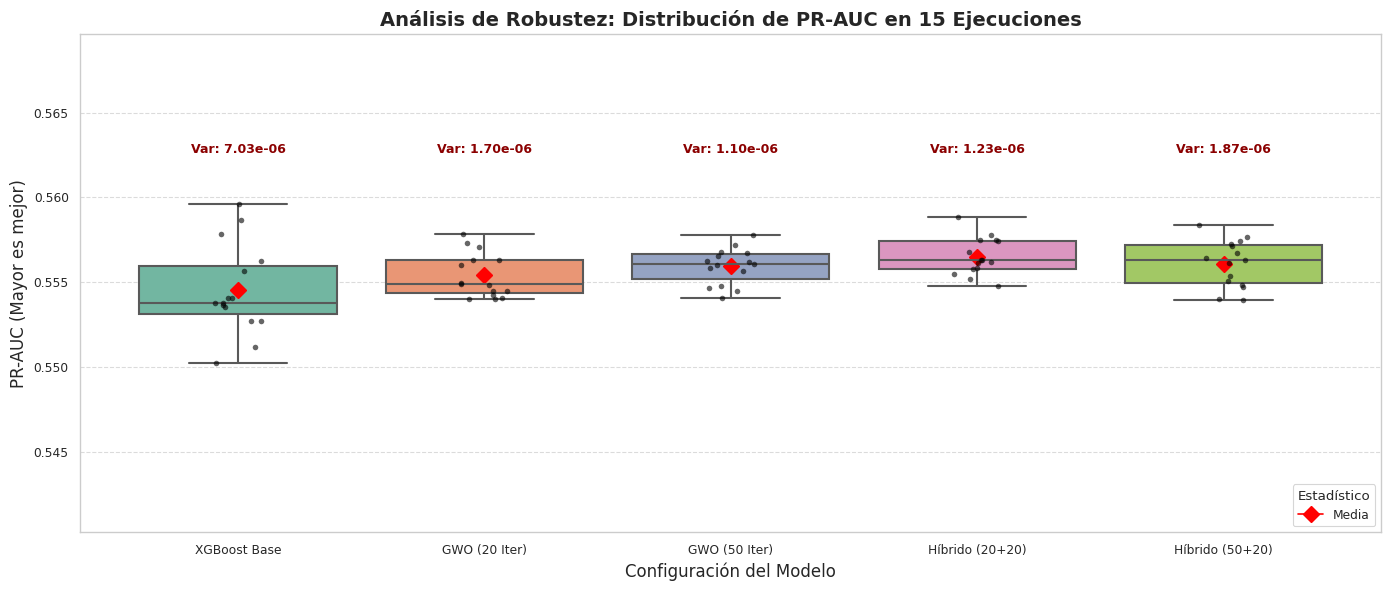

In [17]:
plt.figure(figsize=(14, 6))

df_robust = pd.DataFrame({
    "XGBoost Base": results_base_robust,
    "GWO (20 Iter)": results_gwo_20_robust,
    "GWO (50 Iter)": results_gwo_50_robust,
    "Híbrido (20+20)": results_hybrid_20_robust,
    "Híbrido (50+20)": results_hybrid_50_robust
}).melt(var_name="Modelo", value_name="PR-AUC")

ax = sns.boxplot(data=df_robust, x="Modelo", y="PR-AUC", palette="Set2",
                 linewidth=1.5, fliersize=5)
sns.stripplot(data=df_robust, x="Modelo", y="PR-AUC", color="black",
              size=4, alpha=0.6, jitter=True)

# Calcular estadísticos
models = df_robust["Modelo"].unique()
means = [df_robust[df_robust["Modelo"] == model]["PR-AUC"].mean() for model in models]
variances = [df_robust[df_robust["Modelo"] == model]["PR-AUC"].var() for model in models]

# Añadir medias como puntos destacados (usando enumerate correctamente)
for i, (model, mean) in enumerate(zip(models, means)):
    ax.plot(i, mean, marker='D', color='red', markersize=8, 
            label='Media' if i==0 else "")

plt.title("Análisis de Robustez: Distribución de PR-AUC en 15 Ejecuciones", 
          fontsize=14, fontweight='bold')
plt.ylabel("PR-AUC (Mayor es mejor)", fontsize=12)
plt.xlabel("Configuración del Modelo", fontsize=12)
plt.ylim(min(df_robust["PR-AUC"]) - 0.01, max(df_robust["PR-AUC"]) + 0.01)
plt.legend(title="Estadístico", loc="lower right")
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Anotación de varianza
for i, (model, var, mean_val) in enumerate(zip(models, variances, means)):
    # Usar notación científica para varianzas muy pequeñas
    if var < 0.00001:
        var_text = f'Var: {var:.2e}'  # Notación científica
    else:
        var_text = f'Var: {var:.6f}'
    
    # Posicionar la anotación correctamente
    ax.annotate(var_text, xy=(i, mean_val), xytext=(i, max(df_robust["PR-AUC"]) + 0.003),
                 ha='center', fontsize=9, color='darkred', fontweight='bold')

plt.tight_layout()
plt.show()

# Test de Significancia Estadística (Wilcoxon)
- Aplicamos la prueba no paramétrica de Wilcoxon para pares relacionados.
- Hipótesis Nula (H0): No hay diferencia significativa en el PR-AUC entre los modelos.
- Hipótesis Alternativa (H1): El modelo optimizado con GWO es estadísticamente superior.
- Un p-value < 0.05 nos permite rechazar H0 y afirmar que la mejora NO es por azar.

In [18]:
# 1. Híbrido 20+20 vs Base
stat_h20_base, p_h20_base = wilcoxon(results_hybrid_20_robust, results_base_robust, alternative='greater')
print(f"\n1. Híbrido (20+20) vs XGBoost Base:")
print(f"   Estadístico W: {stat_h20_base:.4f}")
print(f"   p-value: {p_h20_base:.6f} {'✅ SIGNIFICATIVO' if p_h20_base < 0.05 else '❌ NO SIGNIFICATIVO'}")

# 2. Híbrido 50+20 vs Base
stat_h50_base, p_h50_base = wilcoxon(results_hybrid_50_robust, results_base_robust, alternative='greater')
print(f"\n2. Híbrido (50+20) vs XGBoost Base:")
print(f"   Estadístico W: {stat_h50_base:.4f}")
print(f"   p-value: {p_h50_base:.6f} {'✅ SIGNIFICATIVO' if p_h50_base < 0.05 else '❌ NO SIGNIFICATIVO'}")

# 3. Híbrido 20+20 vs GWO 20 (¿MFO aporta mejora significativa?)
stat_h20_g20, p_h20_g20 = wilcoxon(results_hybrid_20_robust, results_gwo_20_robust, alternative='greater')
print(f"\n3. Híbrido (20+20) vs GWO (20):")
print(f"   Estadístico W: {stat_h20_g20:.4f}")
print(f"   p-value: {p_h20_g20:.6f} {'✅ MFO MEJORA SIGNIFICATIVAMENTE' if p_h20_g20 < 0.05 else '❌ MFO NO APORTA MEJORA'}")

# 4. Híbrido 50+20 vs GWO 50
stat_h50_g50, p_h50_g50 = wilcoxon(results_hybrid_50_robust, results_gwo_50_robust, alternative='greater')
print(f"\n4. Híbrido (50+20) vs GWO (50):")
print(f"   Estadístico W: {stat_h50_g50:.4f}")
print(f"   p-value: {p_h50_g50:.6f} {'✅ MFO MEJORA SIGNIFICATIVAMENTE' if p_h50_g50 < 0.05 else '❌ MFO NO APORTA MEJORA'}")

# 5. Híbrido 50+20 vs Híbrido 20+20 (¿50 épocas GWO vale la pena?)
stat_h50_h20, p_h50_h20 = wilcoxon(results_hybrid_50_robust, results_hybrid_20_robust, alternative='greater')
print(f"\n5. Híbrido (50+20) vs Híbrido (20+20):")
print(f"   Estadístico W: {stat_h50_h20:.4f}")
print(f"   p-value: {p_h50_h20:.6f} {'✅ 50 ÉPOCAS GWO VALE LA PENA' if p_h50_h20 < 0.05 else '❌ 20 ÉPOCAS SON SUFICIENTES'}")


1. Híbrido (20+20) vs XGBoost Base:
   Estadístico W: 104.0000
   p-value: 0.005127 ✅ SIGNIFICATIVO

2. Híbrido (50+20) vs XGBoost Base:
   Estadístico W: 91.0000
   p-value: 0.041626 ✅ SIGNIFICATIVO

3. Híbrido (20+20) vs GWO (20):
   Estadístico W: 115.0000
   p-value: 0.000305 ✅ MFO MEJORA SIGNIFICATIVAMENTE

4. Híbrido (50+20) vs GWO (50):
   Estadístico W: 62.0000
   p-value: 0.467041 ❌ MFO NO APORTA MEJORA

5. Híbrido (50+20) vs Híbrido (20+20):
   Estadístico W: 38.0000
   p-value: 0.896118 ❌ 20 ÉPOCAS SON SUFICIENTES
